In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import math
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.parallel import Parallel, delayed
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report




# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


# 1. Data Loading
---
I'll be working on both local VS code instance and on the kaggle hosted notebook therefore both situations need to be accounted when loading the data  

In [2]:
#Load data
#Try to load data from Kaggle input directory, if not found, load from local directory
try:
    print("Loading data from Kaggle input directory...")
    train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
    test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
    sample_submission_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')
    print("Data loaded successfully from Kaggle input directory.")
except FileNotFoundError as e:
    data_path = os.getcwd() + "\\playground_series\\data"
    print("Data not found in Kaggle input directory. Loading from local directory...")
    train_df = pd.read_csv(data_path + "\\train.csv")
    test_df = pd.read_csv(data_path + "\\test.csv")
    sample_submission_df = pd.read_csv(data_path + "\\sample_submission.csv")
    print("Data loaded successfully from local directory.")

Loading data from Kaggle input directory...
Data loaded successfully from Kaggle input directory.


# 2. Data Exploration
---

Exploring the data to check for:
* Missing values.
* Mislabled data types.
* Class Imbalance.
* Outlier values.




In [3]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
train_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [6]:
def summarize_dataframe(df):
    '''Breakdown of dataframe structure, missing values, and duplicates'''
    print("----------------------------------------------------------")
    print("DataFrame Summary:")
    print(f'Number of rows: {df.shape[0]}')
    print(f'Number of columns: {df.shape[1]}')
    print(f'The total number of missing values in the dataset is: {df.isnull().sum().sum()}')
    print(f'The total number of duplicate rows in the dataset is: {df.duplicated().sum()}')
    print(f'The number of numeric columns: {df.select_dtypes(include=[np.number]).shape[1]}')
    print(f'The number of categorical columns: {df.select_dtypes(include=[object]).shape[1]}')
    print("----------------------------------------------------------\n")
summarize_dataframe(train_df)
summarize_dataframe(test_df) 

----------------------------------------------------------
DataFrame Summary:
Number of rows: 630000
Number of columns: 21
The total number of missing values in the dataset is: 0
The total number of duplicate rows in the dataset is: 0
The number of numeric columns: 12
The number of categorical columns: 9
----------------------------------------------------------

----------------------------------------------------------
DataFrame Summary:
Number of rows: 270000
Number of columns: 20
The total number of missing values in the dataset is: 0
The total number of duplicate rows in the dataset is: 0
The number of numeric columns: 12
The number of categorical columns: 8
----------------------------------------------------------



## 2.1 Pie Chart Diagrams

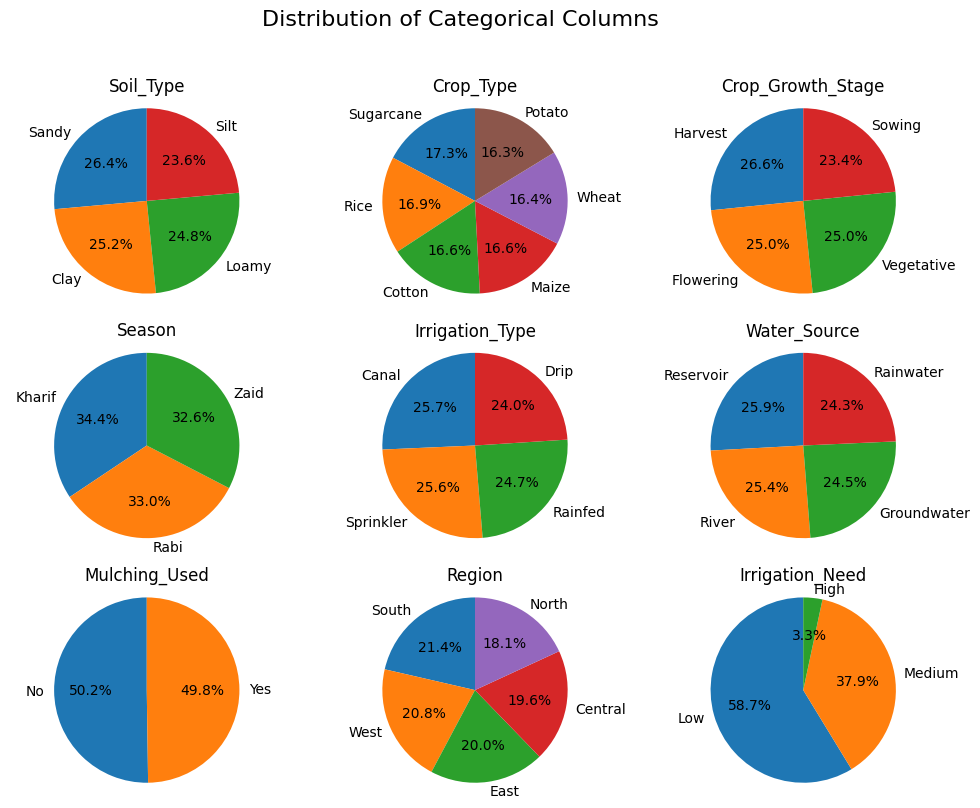

In [7]:
def plot_distribution_pie(df):

    '''Plot distribution of a categorical column as a pie chart with percentage labels in a grid layout'''
    #Creat a grid layout for multiple pie charts
    total_plots = len(df.select_dtypes(include=[object]).columns)

    if total_plots == 0:
        print("No categorical columns to plot.")
        return
    
    if total_plots%4 == 0:
        col = 4
    else:        
        col = 3

    row = math.ceil(total_plots/col)
    
    fig, axs = plt.subplots(nrows=row, ncols=col, figsize=(12, 3*row))
    fig.suptitle('Distribution of Categorical Columns', fontsize=16)

    if total_plots == 1:
        axs = [axs]
    else:
        axs = axs.flatten()
    
    for i, column in enumerate(df.select_dtypes(include=[object]).columns):
        value_counts = df[column].value_counts()
        labels = value_counts.index
        sizes = value_counts.values
        
        axs[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        axs[i].axis('equal')
        axs[i].set_title(column)

    for j in range(total_plots, len(axs)):
        axs[j].set_visible(False)

    plt.show()

plot_distribution_pie(train_df)

## 2.2 Boxplot Diagrams

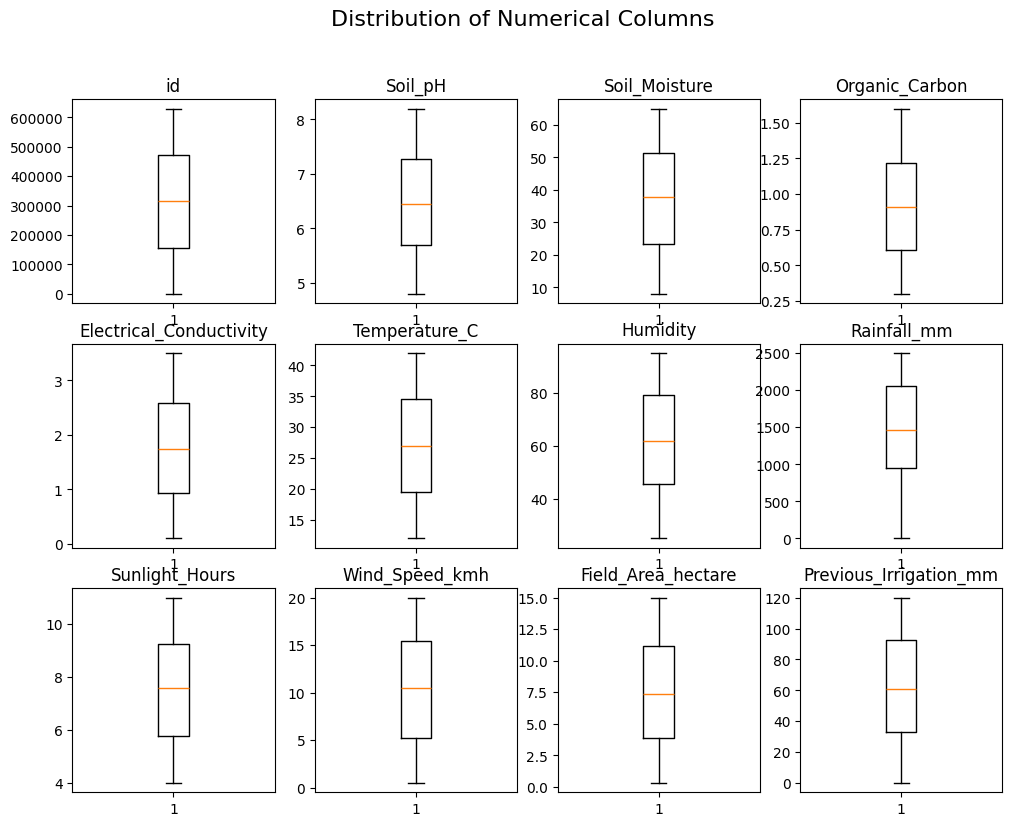

In [8]:
def plot_distribution_boxplot(df):

    '''Plot distribution of a categorical column as a box plot'''
    # Create a grid layout for multiple box plots
    total_plots = len(df.select_dtypes(include=[float, int]).columns)

    if total_plots == 0:
        print("No numerical columns to plot.")
        return
    
    if total_plots%4 == 0:
        col = 4
    else:        
        col = 3

    row = math.ceil(total_plots/col)
    
    fig, axs = plt.subplots(nrows=row, ncols=col, figsize=(12, 3*row))
    fig.suptitle('Distribution of Numerical Columns', fontsize=16)

    if total_plots == 1:
        axs = [axs]
    else:
        axs = axs.flatten()
    
    for i, column in enumerate(df.select_dtypes(include=[float, int]).columns):
        axs[i].boxplot(df[column])
        axs[i].set_title(column)
        

    for j in range(total_plots, len(axs)):
        axs[j].set_visible(False)

    plt.show()

plot_distribution_boxplot(train_df)

# 3. Data Preprocessing
---
Data exploration reveals the following that will need to be addressed:
* **Class Imbalance**: `Irrigation need` target variable is imbalance; High 3.3% , Medium 37.9% and Low 58.7%
* **Different value scales**: The box plots shows that while the numerical fields have a fairly even distribution each field has different maxes and minimums.

## 3.1 Strategy
- Drop `id` column/field/feature as it has no influence on irrigation need.
- Add weights to counter the class imbalance.
- Normalize the data to ensure each column/field is treated equally.
- Encoding categorical fields for easy processing by machine learning models.


In [9]:
def clean_dataframe(df):
    '''Clean dataframe by dropping id column, normalizing numerical columns between 0 and 1, and encoding categorical columns using one-hot encoding for column with 2 unique values to either 0 or 1 and mapping for columns with more than 2 unique values from 1 to n unique values'''
    # Drop the id column
    df = df.drop(columns=['id'])

    # Normalize numerical columns
    numerical_columns = df.select_dtypes(include=[float, int]).columns
    for column in numerical_columns:
        df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())

    # Encode categorical columns
    categorical_columns = df.select_dtypes(include=[object]).columns
    for column in categorical_columns:
        if df[column].nunique() == 2:
            # One-hot encode columns with 2 unique values to either 0 or 1
            df[column] = df[column].map({df[column].unique()[0]: 0, df[column].unique()[1]: 1})
        else:
            # Map columns with more than 2 unique values from 1 to n unique values
            unique_values = df[column].unique()
            value_to_code = {value: code for code, value in enumerate(unique_values, start=1)}
            df[column] = df[column].map(value_to_code)

    return df

train_df_cleaned = clean_dataframe(train_df)

In [10]:
train_df_cleaned.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,1,0.035294,0.431304,0.546154,0.867647,0.100333,0.365909,0.290324,0.271429,0.835385,1,1,1,1,1,0.035374,0,0.934734,1,1
1,2,0.670588,0.852957,0.107692,0.558824,0.364000,0.612373,0.394221,0.425714,0.148205,2,2,2,2,2,0.338095,1,0.392932,2,1
2,2,0.261765,0.345850,0.392308,0.802941,0.499000,0.960423,0.880771,0.292857,0.171795,3,2,2,3,3,0.540136,1,0.919897,3,1
3,3,0.250000,0.093350,0.792308,0.226471,0.044000,0.522503,0.542930,0.731429,0.092821,2,3,2,4,2,0.545578,1,0.448696,2,2
4,2,0.929412,0.897350,0.061538,0.252941,0.274000,0.944564,0.615298,0.421429,0.689231,2,1,3,4,2,0.480952,0,0.776611,2,1


# 4. Model Training
---

## 4.1 Random Forest

In [11]:
def randomforest_model_training(df):
    '''Train a machine learning model on the cleaned dataframe'''
    # Split the data into features and target variable
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train a machine learning model (e.g., Random Forest)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Evaluate the model on the test set
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy:.4f}')
    return model

rf_model = randomforest_model_training(train_df_cleaned)

Accuracy: 0.9855


In [12]:
def train_optimized_rf(df, tuning_sample_size=100000):
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']

    # 1. Representative sample for tuning
    if tuning_sample_size < len(df):
        df_sample = df.sample(n=tuning_sample_size, random_state=42)
        X_tune = df_sample.drop(columns=['Irrigation_Need'])
        y_tune = df_sample['Irrigation_Need']
    else:
        X_tune, y_tune = X, y

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # CRITICAL FIX: Set n_jobs=None here. 
    # Let GridSearchCV handle the parallelism, not the individual trees.
    model = RandomForestClassifier(random_state=42) 

    param_grid = {
        'n_estimators': [100, 200], # Keep tuning light to find the best depth/split
        'max_depth': [15, 20, 25],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    # Bulletproof progress: verbose=1 provides a reliable textual progress bar
    # n_jobs=-1 here will use all cores efficiently now that n_jobs is None above.
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                               cv=3, n_jobs=-1, verbose=1)
    
    print(f"Phase 1: Tuning on {tuning_sample_size} rows...")
    grid_search.fit(X_tune, y_tune)

    print(f"\nBest Settings Found: {grid_search.best_params_}")
    
    # 2. Final Training: Now we use the full power for the final model
    print("\nPhase 2: Training final model on full dataset (630k rows)...")
    best_params = grid_search.best_params_
    best_params['n_estimators'] = 300 # Use more trees for the final version
    
    # Use n_jobs=-1 here because it's a single model training
    final_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_train, y_train) 
    
    y_pred = final_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Final Accuracy: {accuracy:.4f}")
    
    return final_model

# Run the bulletproof version
best_rf_model = train_optimized_rf(train_df_cleaned, tuning_sample_size=100000)

Phase 1: Tuning on 100000 rows...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Settings Found: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Phase 2: Training final model on full dataset (630k rows)...
Final Accuracy: 0.9855


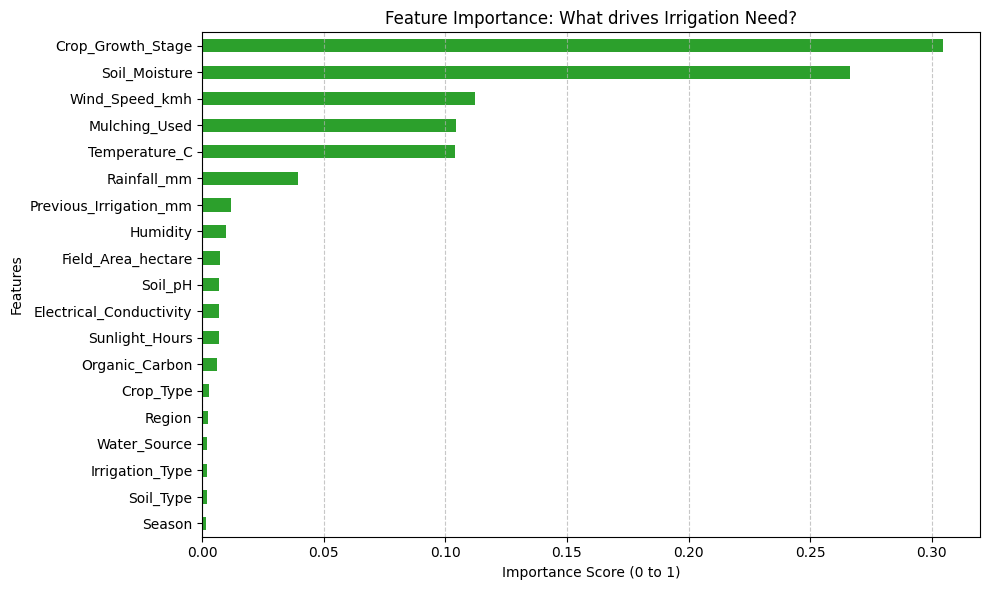


--- Feature Importance Rankings (Numerical) ---
Crop_Growth_Stage          0.304583
Soil_Moisture              0.266372
Wind_Speed_kmh             0.112122
Mulching_Used              0.104364
Temperature_C              0.104152
Rainfall_mm                0.039205
Previous_Irrigation_mm     0.012042
Humidity                   0.009877
Field_Area_hectare         0.007151
Soil_pH                    0.006916
Electrical_Conductivity    0.006884
Sunlight_Hours             0.006853
Organic_Carbon             0.006302
Crop_Type                  0.002794
Region                     0.002421
Water_Source               0.002177
Irrigation_Type            0.002133
Soil_Type                  0.002059
Season                     0.001592


In [13]:
def plot_feature_importance(df, model):
    '''Visualize which features are driving the model's predictions and print numerical rankings'''
    
    # 1. Get the feature names (everything except the target)
    feature_names = df.drop(columns=['Irrigation_Need']).columns
    
    # 2. Extract importances from the model
    importances = model.feature_importances_
    
    # 3. Create a Series for easy sorting and plotting
    feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    # 4. Create the plot
    plt.figure(figsize=(10, 6))
    feature_importance_df.plot(kind='barh', color='#2ca02c') # Green for irrigation context
    
    plt.title('Feature Importance: What drives Irrigation Need?')
    plt.xlabel('Importance Score (0 to 1)')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 5. Print numerical values sorted descending (highest importance at the top)
    print("\n--- Feature Importance Rankings (Numerical) ---")
    print(feature_importance_df.sort_values(ascending=False).to_string())

# Example usage:
plot_feature_importance(train_df_cleaned, best_rf_model)

**Feature Pruning (Simplify to Amplify)**

Training the model using only the top 8 features (everything from `Crop_Growth_Stage` down to `Humidity`).Removing the bottom 11 features (which contribute less than 1% each) can reduce noise and prevent the model from making slight errors based on irrelevant data like `Region` or `Water_Source`.

In [14]:
def prune_features_by_importance(df, model, threshold=0.005):
    '''
    Automatically drops features from the dataframe that have an 
    importance score below the specified threshold.
    '''
    # 1. Get feature names and importances
    # Assumes 'Irrigation_Need' is the target and not in the model features
    feature_cols = df.drop(columns=['Irrigation_Need']).columns
    importances = model.feature_importances_
    
    # 2. Create a mapping and identify "noisy" columns
    feature_importance_map = pd.Series(importances, index=feature_cols)
    
    noisy_features = feature_importance_map[feature_importance_map < threshold].index.tolist()
    kept_features = feature_importance_map[feature_importance_map >= threshold].index.tolist()
    
    print("--- Feature Pruning Report ---")
    print(f"Threshold set at: {threshold}")
    print(f"Features to DROP ({len(noisy_features)}): {noisy_features}")
    print(f"Features to KEEP ({len(kept_features)}): {kept_features}")
    print("------------------------------")
    
    # 3. Create the pruned dataframe (keep target variable)
    pruned_df = df[kept_features + ['Irrigation_Need']].copy()
    
    return pruned_df


train_df_pruned = prune_features_by_importance(train_df_cleaned, best_rf_model, threshold=0.01)

--- Feature Pruning Report ---
Threshold set at: 0.01
Features to DROP (12): ['Soil_Type', 'Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Humidity', 'Sunlight_Hours', 'Crop_Type', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Region']
Features to KEEP (7): ['Soil_Moisture', 'Temperature_C', 'Rainfall_mm', 'Wind_Speed_kmh', 'Crop_Growth_Stage', 'Mulching_Used', 'Previous_Irrigation_mm']
------------------------------


**Training on the pruned dataset...**

In [15]:
pruned_rf_model = train_optimized_rf(train_df_pruned, tuning_sample_size=100000)

Phase 1: Tuning on 100000 rows...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Settings Found: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Phase 2: Training final model on full dataset (630k rows)...
Final Accuracy: 0.9856


## 4.2 XGBoost (Gradient Boosting)

Random Forests work by building many independent trees and taking the average. Because the top features (`Crop_Growth_Stage` and `Soil_Moisture`) are so dominant, almost every tree is reaching the same conclusion hence we are reaching an 'averaging limit'. Averaging 300 nearly identical trees won't change the final result.

XGboost uses the gradient to improve upon each trees 'shortcomings'.


In [16]:
def xgboost_model_training(df):
    '''Train an XGBoost model to break the accuracy plateau'''
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']

    # XGBoost often expects 0-indexed targets. 
    # If your Irrigation_Need is 1 and 2, we subtract 1.
    if y.min() == 1:
        y = y - 1

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize XGBoost
    # use_label_encoder=False removes a common warning in newer versions
    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05, # Smaller steps lead to better accuracy
        max_depth=6,        # XGBoost trees are usually shallower than RF
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Speeds up training significantly
    )

    print("Training XGBoost model...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'XGBoost Final Accuracy: {accuracy:.4f}')
    
    return model


xgb_model = xgboost_model_training(train_df_pruned)

Training XGBoost model...
XGBoost Final Accuracy: 0.9844


## 4.3 Feature Engineering

Added 4 interaction features. New shape: (630000, 12)

Training Random Forest with interaction features...
Accuracy: 0.9854


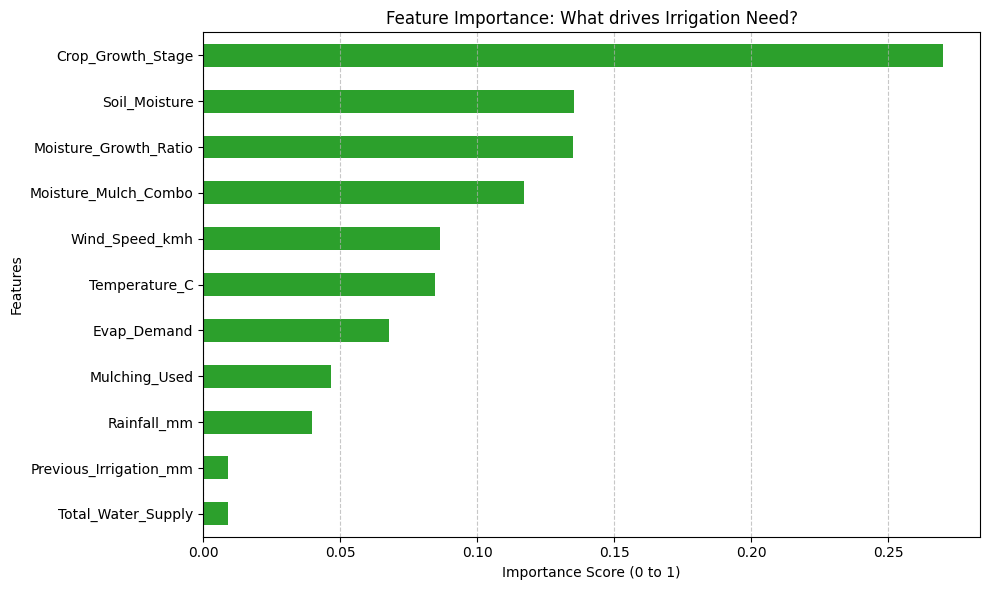


--- Feature Importance Rankings (Numerical) ---
Crop_Growth_Stage         0.270045
Soil_Moisture             0.135283
Moisture_Growth_Ratio     0.135121
Moisture_Mulch_Combo      0.116962
Wind_Speed_kmh            0.086322
Temperature_C             0.084610
Evap_Demand               0.067738
Mulching_Used             0.046501
Rainfall_mm               0.039616
Previous_Irrigation_mm    0.008910
Total_Water_Supply        0.008891


In [17]:
def add_interaction_features(df):
    '''
    Creates new features using only the variables kept after pruning 
    (Soil_Moisture, Crop_Growth_Stage, Wind_Speed, Temperature, etc.)
    '''
    df_engineered = df.copy()

    # 1. Moisture-to-Growth Ratio 
    # High impact: Shows if moisture is sufficient for the current life stage
    df_engineered['Moisture_Growth_Ratio'] = df_engineered['Soil_Moisture'] / (df_engineered['Crop_Growth_Stage'] + 1)

    # 2. Evaporative Demand (Wind + Temperature)
    # Replaces 'Heat Stress'. High wind + high temp = high soil drying rate
    df_engineered['Evap_Demand'] = df_engineered['Wind_Speed_kmh'] * df_engineered['Temperature_C']

    # 3. Moisture Retention Potential (Moisture + Mulching)
    # Mulching helps keep moisture in; this interaction captures that synergy
    df_engineered['Moisture_Mulch_Combo'] = df_engineered['Soil_Moisture'] * df_engineered['Mulching_Used']

    # 4. Total Water Supply
    # Sum of environmental water and previous manual irrigation
    df_engineered['Total_Water_Supply'] = df_engineered['Rainfall_mm'] + df_engineered['Previous_Irrigation_mm']

    print(f"Added 4 interaction features. New shape: {df_engineered.shape}")
    return df_engineered


train_df_engineered = add_interaction_features(train_df_pruned)

print("\nTraining Random Forest with interaction features...")
best_rf_model_engineered = randomforest_model_training(train_df_engineered)

# 3. Check the new Feature Importance rankings
plot_feature_importance(train_df_engineered, best_rf_model_engineered)

Moisture_Growth_Ratio (0.135): This is now just as important as the raw Soil_Moisture.

Moisture_Mulch_Combo (0.116): This outperformed raw Wind_Speed and Temperature.

### 4.3.1 Confusion matrix

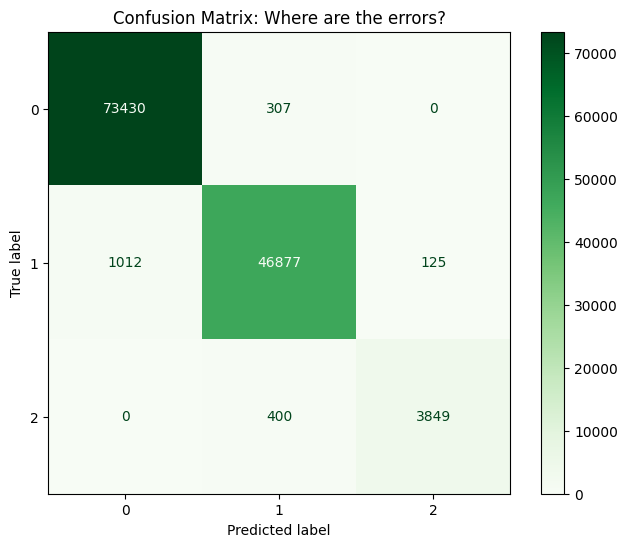

In [18]:
def plot_confusion_matrix(df, model):
    '''Visualize where the model is making mistakes'''
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']
    
    # Use the same split as training for a fair test
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Greens', ax=ax)
    
    plt.title('Confusion Matrix: Where are the errors?')
    plt.show()


plot_confusion_matrix(train_df_engineered, best_rf_model_engineered)

In [19]:
def evaluate_model_performance(df, model):
    '''Modular function to print confusion matrix and classification report for any number of classes'''
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    y_pred = model.predict(X_test)
    labels = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred)

    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_test, y_pred))

    print("--- Text-Based Confusion Matrix ---")
    # Dynamic header based on labels found in data
    header = " | ".join([f"Pred: {l}" for l in labels])
    print(f"{'':>12} | {header}")
    print("-" * (15 + 13 * len(labels)))
    
    for i, label in enumerate(labels):
        row = " | ".join([f"{cm[i][j]:^10}" for j in range(len(labels))])
        print(f"Actual: {label:<4} | {row}")
    print("-" * (15 + 13 * len(labels)))
# Execute the summary
evaluate_model_performance(train_df_engineered, best_rf_model_engineered)


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           1       0.99      1.00      0.99     73737
           2       0.99      0.98      0.98     48014
           3       0.97      0.91      0.94      4249

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

--- Text-Based Confusion Matrix ---
             | Pred: 1 | Pred: 2 | Pred: 3
------------------------------------------------------
Actual: 1    |   73430    |    307     |     0     
Actual: 2    |    1012    |   46877    |    125    
Actual: 3    |     0      |    400     |    3849   
------------------------------------------------------


In [20]:
def evaluate_custom_threshold(df, model, target_class=3, threshold=0.4):
    '''
    Evaluates the model by lowering the threshold for a specific class 
    to improve recall on critical irrigation needs.
    '''
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 1. Get probabilities instead of hard predictions
    # This returns a matrix of [Prob_Class_1, Prob_Class_2, Prob_Class_3]
    probs = model.predict_proba(X_test)
    
    # 2. Extract the probability for Class 3 (index 2)
    # If prob > threshold, we force it to Class 3; otherwise, take the highest prob
    y_pred_custom = []
    for p in probs:
        if p[target_class - 1] >= threshold:
            y_pred_custom.append(target_class)
        else:
            y_pred_custom.append(np.argmax(p) + 1)

    # 3. Print the results using the same format as before
    print(f"--- Results with {int(threshold*100)}% Threshold for Class {target_class} ---")
    print(classification_report(y_test, y_pred_custom))
    
    cm = confusion_matrix(y_test, y_pred_custom)
    labels = sorted(y.unique())
    header = " | ".join([f"Pred: {l}" for l in labels])
    print(f"{'':>12} | {header}")
    print("-" * (15 + 13 * len(labels)))
    for i, label in enumerate(labels):
        row = " | ".join([f"{cm[i][j]:^10}" for j in range(len(labels))])
        print(f"Actual: {label:<4} | {row}")

evaluate_custom_threshold(train_df_engineered, best_rf_model_engineered, target_class=3, threshold=0.4)

--- Results with 40% Threshold for Class 3 ---
              precision    recall  f1-score   support

           1       0.99      1.00      0.99     73737
           2       0.99      0.98      0.98     48014
           3       0.96      0.91      0.94      4249

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

             | Pred: 1 | Pred: 2 | Pred: 3
------------------------------------------------------
Actual: 1    |   73430    |    307     |     0     
Actual: 2    |    1012    |   46843    |    159    
Actual: 3    |     0      |    366     |    3883   


In [21]:
# Testing a 30% threshold to see if we can catch the majority of those 366 errors
evaluate_custom_threshold(train_df_engineered,  best_rf_model_engineered, target_class=3, threshold=0.30)

--- Results with 30% Threshold for Class 3 ---
              precision    recall  f1-score   support

           1       0.99      1.00      0.99     73737
           2       0.99      0.97      0.98     48014
           3       0.95      0.92      0.93      4249

    accuracy                           0.99    126000
   macro avg       0.97      0.96      0.97    126000
weighted avg       0.98      0.99      0.98    126000

             | Pred: 1 | Pred: 2 | Pred: 3
------------------------------------------------------
Actual: 1    |   73430    |    307     |     0     
Actual: 2    |    1012    |   46776    |    226    
Actual: 3    |     0      |    343     |    3906   


## 4.4 Addressing Class Imbalance

### 4.4.1 Random forest balanced

In [22]:
def train_balanced_rf(df):
    '''Train a Random Forest model using balanced class weights to address the 3.3% High-Need class'''
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Re-using the optimal parameters found earlier, but adding class_weight
    model = RandomForestClassifier(
        n_estimators=300, 
        max_depth=20, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1
    )

    print("Training Balanced Random Forest model...")
    model.fit(X_train, y_train)
    
    return model

# Execute and compare
balanced_rf_model = train_balanced_rf(train_df_engineered)

Training Balanced Random Forest model...



--- Detailed Classification Report ---
              precision    recall  f1-score   support

           1       0.99      1.00      0.99     73737
           2       0.99      0.98      0.98     48014
           3       0.97      0.91      0.94      4249

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

--- Text-Based Confusion Matrix ---
             | Pred: 1 | Pred: 2 | Pred: 3
------------------------------------------------------
Actual: 1    |   73425    |    312     |     0     
Actual: 2    |    1001    |   46883    |    130    
Actual: 3    |     0      |    382     |    3867   
------------------------------------------------------


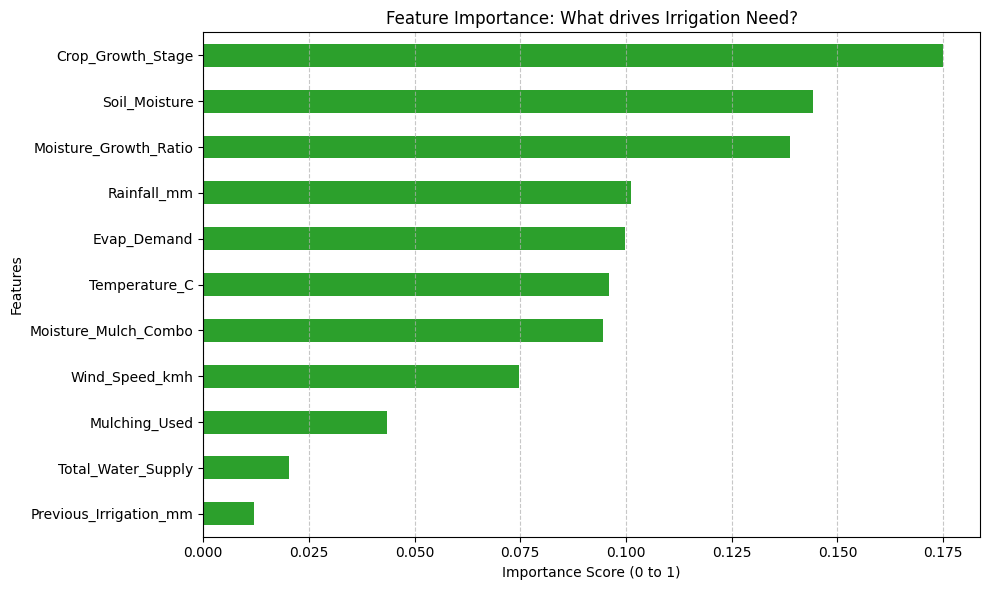


--- Feature Importance Rankings (Numerical) ---
Crop_Growth_Stage         0.174962
Soil_Moisture             0.144260
Moisture_Growth_Ratio     0.138872
Rainfall_mm               0.101125
Evap_Demand               0.099810
Temperature_C             0.096062
Moisture_Mulch_Combo      0.094590
Wind_Speed_kmh            0.074576
Mulching_Used             0.043410
Total_Water_Supply        0.020359
Previous_Irrigation_mm    0.011974


In [23]:
#Evaluate Accuracy and Class 3 (High Need) Recall
evaluate_model_performance(train_df_engineered, balanced_rf_model)

#Check if the 'Balanced' logic changed feature importance
plot_feature_importance(train_df_engineered, balanced_rf_model)

## 4.5 SMOTE (Synthetic Minority Over-sampling Technique)

This technique doesn't just copy the "High" rows; it creates new, synthetic examples by mathematically "interpolating" between existing High-need data points. This gives the model a much richer dataset to learn from.

In [24]:
def apply_smote_balancing(df):
    '''
    Synthetically creates new samples for the minority class (High Need)
    to give the model more training data to learn from.
    '''
    X = df.drop(columns=['Irrigation_Need'])
    y = df['Irrigation_Need']
    
    # Initialize SMOTE
    smote = SMOTE(random_state=42)
    
    # Create the synthetic samples
    X_resampled, y_resampled = smote.fit_resample(X, y)
    
    # Recombine into a dataframe
    df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
    df_balanced['Irrigation_Need'] = y_resampled
    
    print("--- SMOTE Resampling Report ---")
    print(f"Original shape: {df.shape}")
    print(f"Balanced shape: {df_balanced.shape}")
    print(f"New Class Distribution:\n{df_balanced['Irrigation_Need'].value_counts()}")
    
    return df_balanced

In [25]:
train_df_smote = apply_smote_balancing(train_df_engineered)

--- SMOTE Resampling Report ---
Original shape: (630000, 12)
Balanced shape: (1109751, 12)
New Class Distribution:
Irrigation_Need
1    369917
2    369917
3    369917
Name: count, dtype: int64


In [26]:
smote_model = train_balanced_rf(train_df_smote)

Training Balanced Random Forest model...


In [27]:
evaluate_model_performance(train_df_engineered, smote_model)


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           1       0.99      1.00      0.99     73737
           2       0.99      0.98      0.99     48014
           3       0.96      0.98      0.97      4249

    accuracy                           0.99    126000
   macro avg       0.98      0.99      0.98    126000
weighted avg       0.99      0.99      0.99    126000

--- Text-Based Confusion Matrix ---
             | Pred: 1 | Pred: 2 | Pred: 3
------------------------------------------------------
Actual: 1    |   73521    |    216     |     0     
Actual: 2    |    759     |   47086    |    169    
Actual: 3    |     0      |     87     |    4162   
------------------------------------------------------


# 5. Submission

In [29]:
# 1. Define the exact mapping used in your clean_dataframe function
# Based on the sample_submission, these must be exact
label_map_inverse = {1: 'Low', 2: 'Medium', 3: 'High'}

# 2. Process the test data using your established modular pipeline
test_cleaned = clean_dataframe(test_df)
base_features = ['Soil_Moisture', 'Temperature_C', 'Rainfall_mm', 'Wind_Speed_kmh', 
                 'Crop_Growth_Stage', 'Mulching_Used', 'Previous_Irrigation_mm']
test_pruned = test_cleaned[base_features].copy()
test_final = add_interaction_features(test_pruned)

# 3. Generate the numeric predictions
numeric_preds = smote_model.predict(test_final)

# 4. CONVERSION STEP: Map numbers to strings
# This is the step that was missing
final_string_labels = [label_map_inverse[p] for p in numeric_preds]

# 5. Create the final submission
submission = pd.DataFrame({
    'id': test_df['id'], 
    'Irrigation_Need': final_string_labels
})

# 6. Final Save
submission.to_csv('submission.csv', index=False)
print("Submission file saved with correct String labels!")

Added 4 interaction features. New shape: (270000, 11)
Submission file saved with correct String labels!
